# OOD Main3 Attention Feature Importance

This notebook analyzes which attention features matter most for OOD generalization in the saved Main3 consistency XGBoost runs.

It is organized into two sections:
1. `Single Source`
2. `Multi-source`

Within each section, the notebook keeps models separate, picks the best-performing attention-only feature-space variant for each model and target, then averages normalized feature importance across the relevant training splits.


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "ood_main3_attention_feature_importance_lib.py").exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import ood_main3_attention_feature_importance_lib as attention_importance


attention_importance = importlib.reload(attention_importance)


In [2]:
RESULTS_ROOT = Path(
    "/playpen-ssd/smerrill/deception2/Results/OOD_Modeling_main3_consistency_xgb_pca_64_128_256"
)
# Example alternate path:
# RESULTS_ROOT = Path(
#     "/playpen-ssd/smerrill/deception2/Results/OOD_Modeling_main3_consistency_xgb_pca_256only2"
# )

RESULTS_ROOT = RESULTS_ROOT.expanduser().resolve()
print(f"Using results root: {RESULTS_ROOT}")


Using results root: /playpen-ssd/smerrill/deception2/Results/OOD_Modeling_main3_consistency_xgb_pca_64_128_256


# OOD Main3 Attention Feature Importance

Results root: `/playpen-ssd/smerrill/deception2/Results/OOD_Modeling_main3_consistency_xgb_pca_64_128_256`

This notebook focuses on attention-feature importance for OOD generalization in the saved XGBoost runs. It uses the saved per-split coefficient files, averages feature importance across datasets within a model, and keeps models separate.

## 1. Single Source

Train on 1 environment and average feature importance across the five source-specific models for each LLM.

Method: for each model and target, use the fixed full feature space, then average normalized XGBoost gain shares across the relevant training splits. The figures do not average across models.

### delta_deception_rate > 0.3

#### By Model

,Model,Training Splits,Selected Features,OOD AUROC,Validation AUROC
0,GPT-OSS-20B,5,741,0.639 +/- 0.015,0.754 +/- 0.021
1,Llama-8B,5,562,0.604 +/- 0.012,0.776 +/- 0.027
2,Qwen-7B,5,1426,0.691 +/- 0.002,0.787 +/- 0.021


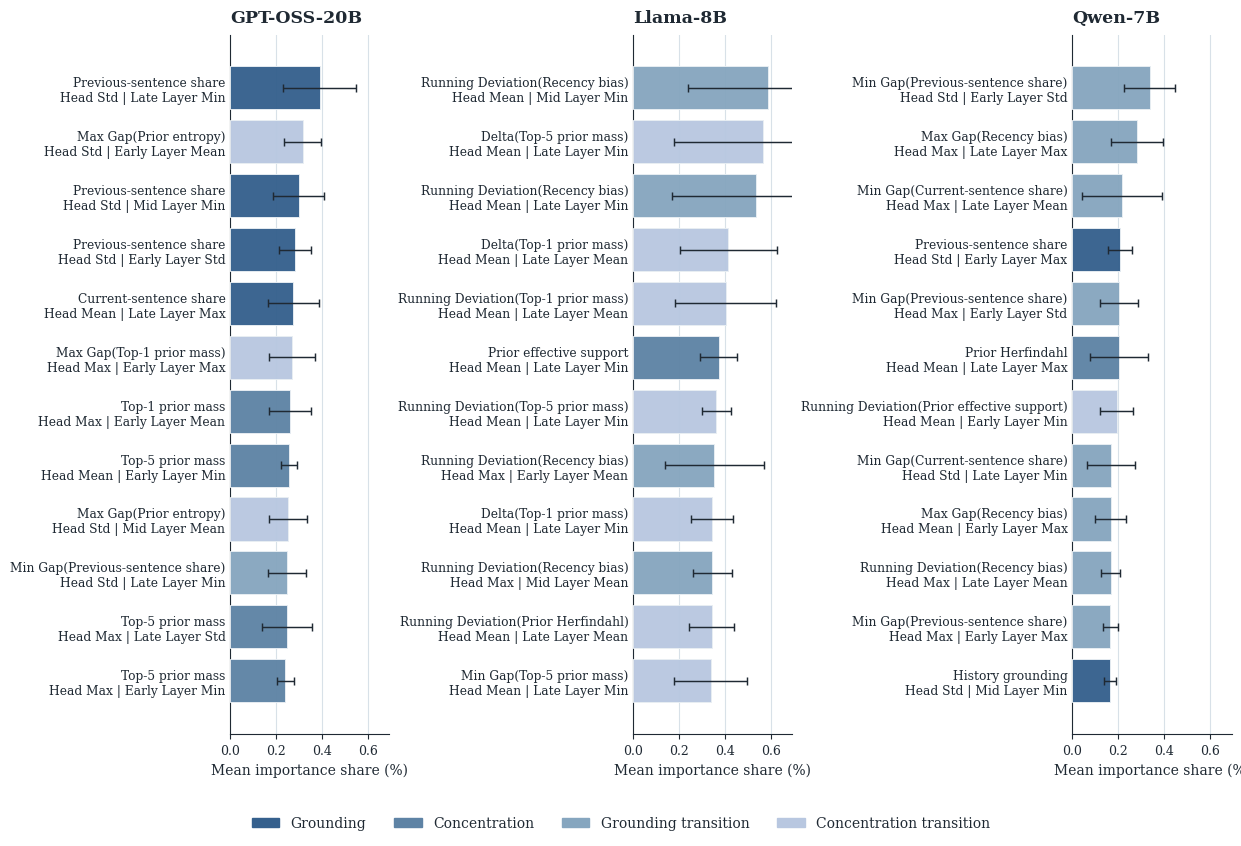

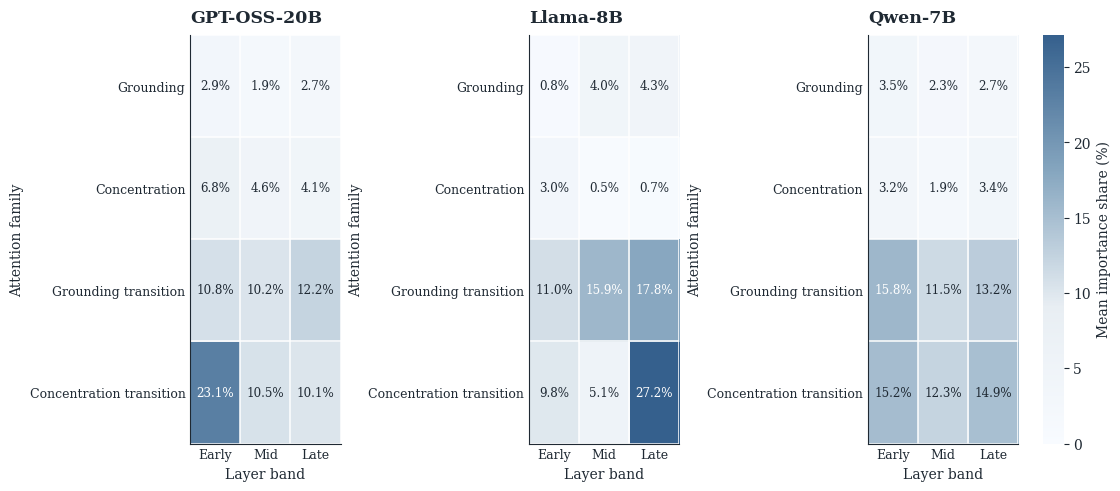

#### Attention Family By Layer Band Tables

##### GPT-OSS-20B

band,Attention Family,Early,Mid,Late
0,Grounding,2.9%,1.9%,2.7%
1,Concentration,6.8%,4.6%,4.1%
2,Grounding transition,10.8%,10.2%,12.2%
3,Concentration transition,23.1%,10.5%,10.1%


##### Llama-8B

band,Attention Family,Early,Mid,Late
0,Grounding,0.8%,4.0%,4.3%
1,Concentration,3.0%,0.5%,0.7%
2,Grounding transition,11.0%,15.9%,17.8%
3,Concentration transition,9.8%,5.1%,27.2%


...

##### Qwen-7B
- OOD AUROC: `0.691 +/- 0.002`
- Validation AUROC: `0.787 +/- 0.021`
- Training splits averaged: `5`

,Rank,Feature,Mean Importance Share,SE,Group,Band,Stat,Head Summary
0,1,Min Gap(Previous-sentence share),0.34%,0.11%,Grounding transition,Early,Std,Head Std
1,2,Max Gap(Recency bias),0.28%,0.11%,Grounding transition,Late,Max,Head Max
2,3,Min Gap(Current-sentence share),0.22%,0.18%,Grounding transition,Late,Mean,Head Max
3,4,Previous-sentence share,0.21%,0.05%,Grounding,Early,Max,Head Std
4,5,Min Gap(Previous-sentence share),0.20%,0.08%,Grounding transition,Early,Std,Head Max
5,6,Prior Herfindahl,0.20%,0.13%,Concentration,Late,Max,Head Mean
6,7,Running Deviation(Prior effective support),0.19%,0.07%,Concentration transition,Early,Min,Head Mean
7,8,Min Gap(Current-sentence share),0.17%,0.10%,Grounding transition,Late,Min,Head Std
8,9,Max Gap(Recency bias),0.17%,0.07%,Grounding transition,Early,Max,Head Mean
9,10,Running Deviation(Recency bias),0.17%,0.04%,Grounding transition,Late,Mean,Head Max


### delta_deception_rate < -0.3

#### By Model

,Model,Training Splits,Selected Features,OOD AUROC,Validation AUROC
0,GPT-OSS-20B,5,499,0.679 +/- 0.013,0.851 +/- 0.023
1,Llama-8B,5,602,0.583 +/- 0.029,0.745 +/- 0.041
2,Qwen-7B,5,1085,0.619 +/- 0.006,0.735 +/- 0.015


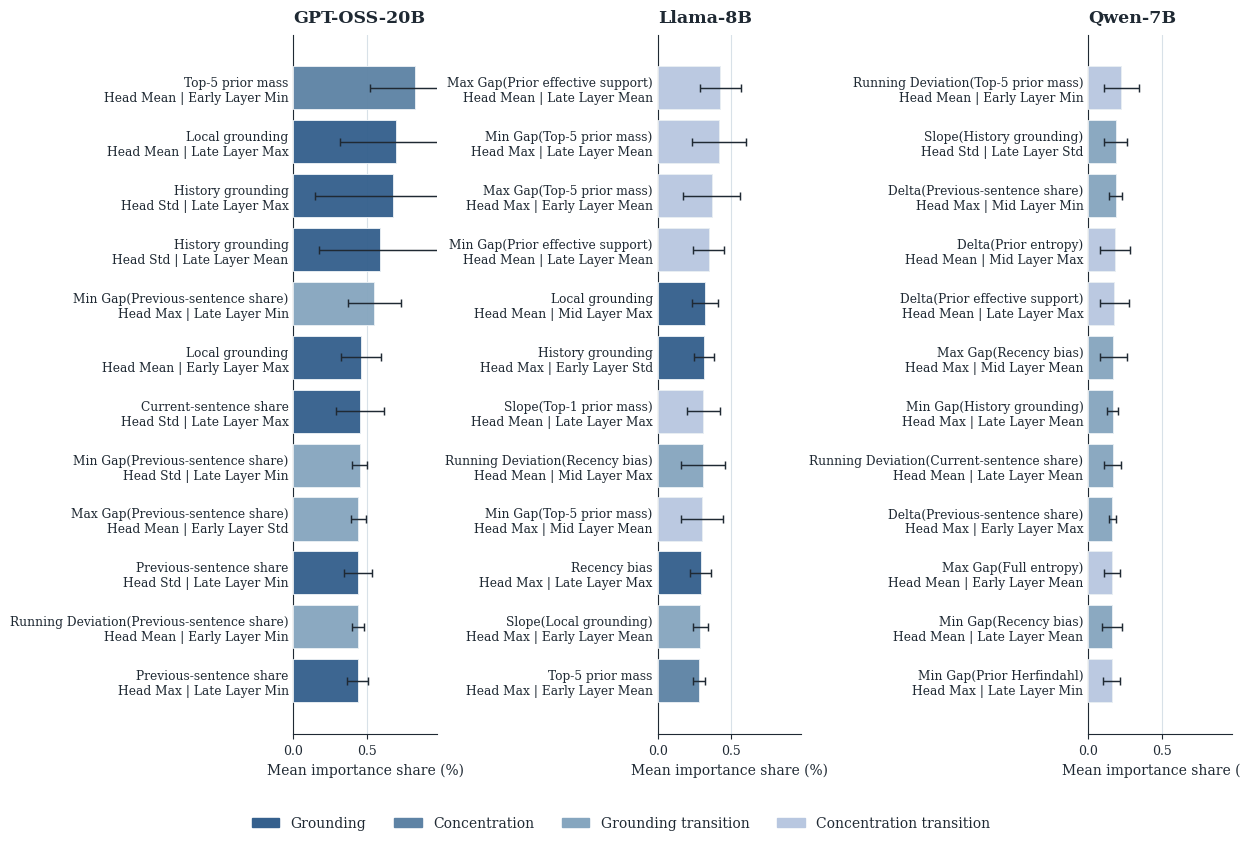

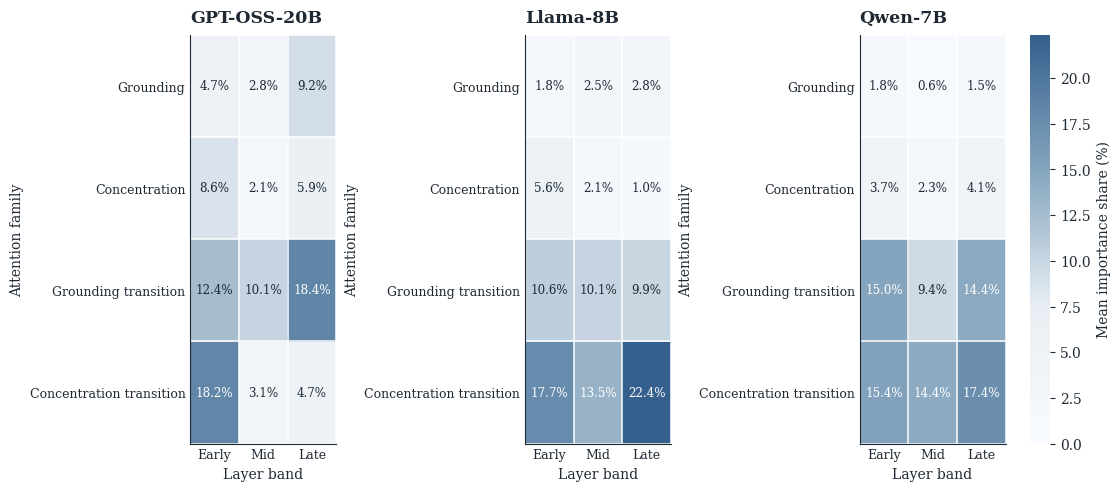

#### Attention Family By Layer Band Tables

##### GPT-OSS-20B

band,Attention Family,Early,Mid,Late
0,Grounding,4.7%,2.8%,9.2%
1,Concentration,8.6%,2.1%,5.9%
2,Grounding transition,12.4%,10.1%,18.4%
3,Concentration transition,18.2%,3.1%,4.7%


##### Llama-8B

band,Attention Family,Early,Mid,Late
0,Grounding,1.8%,2.5%,2.8%
1,Concentration,5.6%,2.1%,1.0%
2,Grounding transition,10.6%,10.1%,9.9%
3,Concentration transition,17.7%,13.5%,22.4%


...

,Rank,Feature,Mean Importance Share,SE,Group,Band,Stat,Head Summary
0,1,Running Deviation(Top-5 prior mass),0.23%,0.12%,Concentration transition,Early,Min,Head Mean
1,2,Slope(History grounding),0.19%,0.08%,Grounding transition,Late,Std,Head Std
2,3,Delta(Previous-sentence share),0.19%,0.04%,Grounding transition,Mid,Min,Head Max
3,4,Delta(Prior entropy),0.18%,0.10%,Concentration transition,Mid,Max,Head Mean
4,5,Delta(Prior effective support),0.18%,0.10%,Concentration transition,Late,Max,Head Mean
5,6,Max Gap(Recency bias),0.17%,0.09%,Grounding transition,Mid,Mean,Head Max
6,7,Min Gap(History grounding),0.17%,0.04%,Grounding transition,Late,Mean,Head Max
7,8,Running Deviation(Current-sentence share),0.17%,0.06%,Grounding transition,Late,Mean,Head Mean
8,9,Delta(Previous-sentence share),0.16%,0.02%,Grounding transition,Early,Max,Head Max
9,10,Max Gap(Full entropy),0.16%,0.05%,Concentration transition,Early,Mean,Head Mean


### Average of truthful and deceptive commitment

This section averages the saved feature-importance summaries from the deceptive-commitment target (`delta_deception_rate > 0.3`) and the truthful-commitment target (`delta_deception_rate < -0.3`).

#### By Model

,Model,Training Splits,Selected Features,OOD AUROC,Validation AUROC
0,GPT-OSS-20B,10,620,0.659 +/- 0.020,0.803 +/- 0.048
1,Llama-8B,10,582,0.594 +/- 0.011,0.761 +/- 0.016
2,Qwen-7B,10,1256,0.655 +/- 0.036,0.761 +/- 0.026


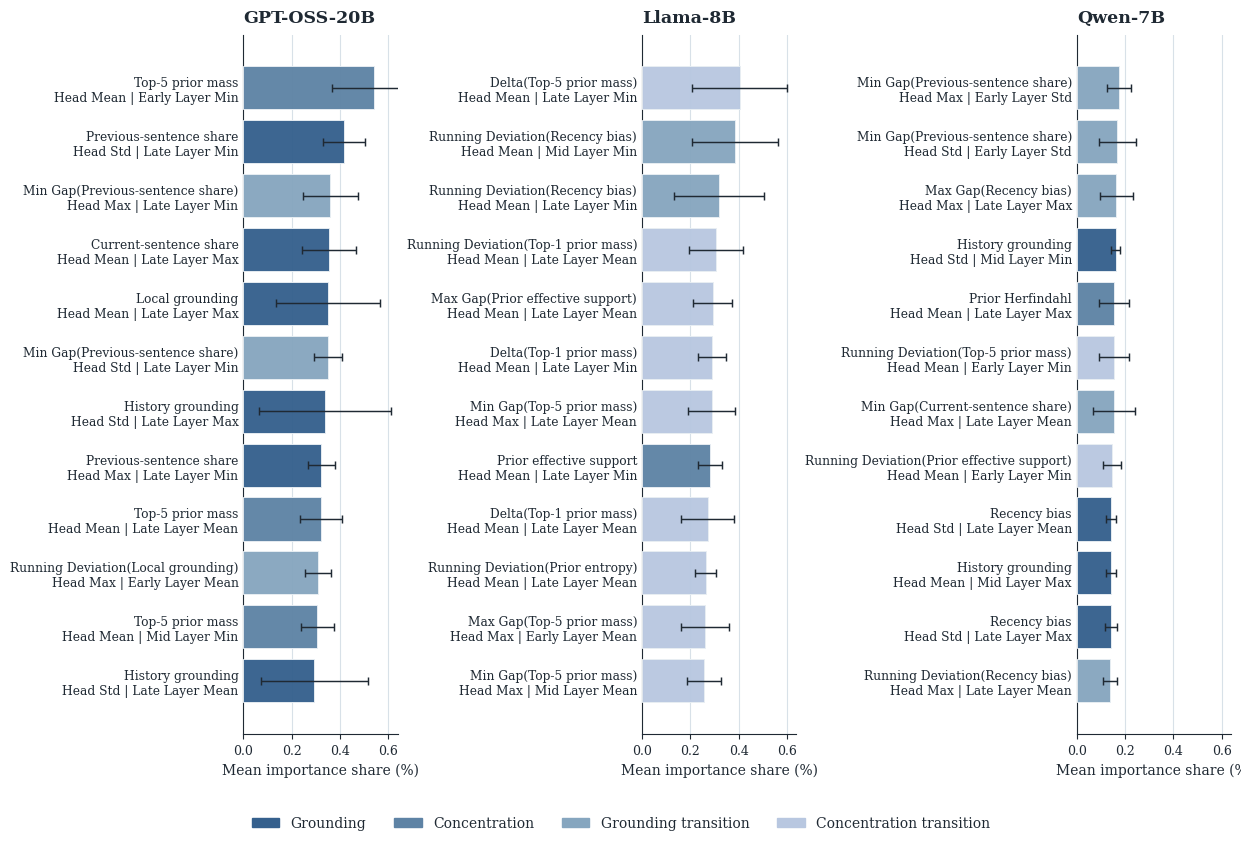

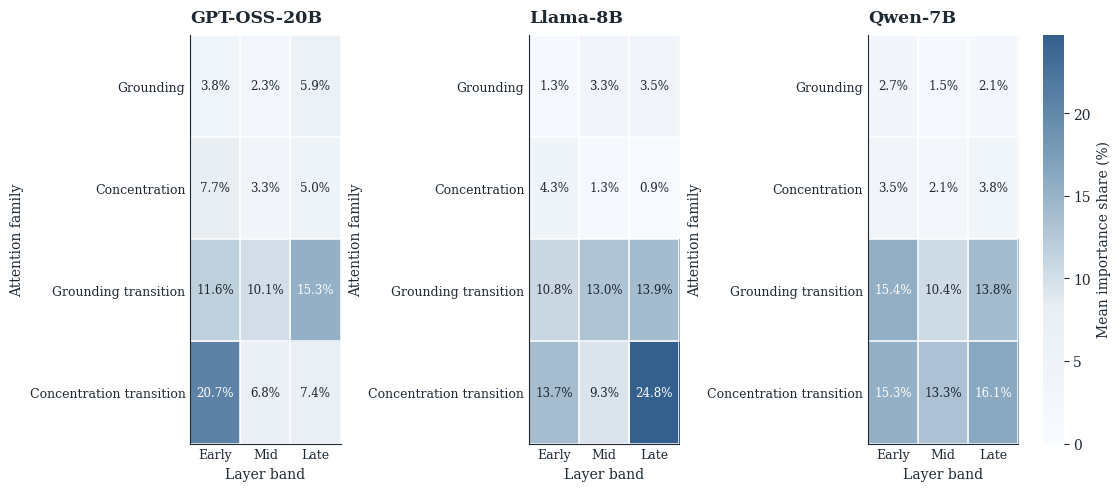

#### Attention Family By Layer Band Tables

##### GPT-OSS-20B

band,Attention Family,Early,Mid,Late
0,Grounding,3.8%,2.3%,5.9%
1,Concentration,7.7%,3.3%,5.0%
2,Grounding transition,11.6%,10.1%,15.3%
3,Concentration transition,20.7%,6.8%,7.4%


##### Llama-8B

band,Attention Family,Early,Mid,Late
0,Grounding,1.3%,3.3%,3.5%
1,Concentration,4.3%,1.3%,0.9%
2,Grounding transition,10.8%,13.0%,13.9%
3,Concentration transition,13.7%,9.3%,24.8%


...

## 2. Multi-source

Train on 4 environments, hold one environment out, and average feature importance across the five held-out splits for each LLM.

Method: for each model and target, use the fixed full feature space, then average normalized XGBoost gain shares across the relevant training splits. The figures do not average across models.

### delta_deception_rate > 0.3

#### By Model

,Model,Training Splits,Selected Features,OOD AUROC,Validation AUROC
0,GPT-OSS-20B,5,741,0.690 +/- 0.029,0.751 +/- 0.004
1,Llama-8B,5,562,0.613 +/- 0.033,0.736 +/- 0.014
2,Qwen-7B,5,1426,0.734 +/- 0.010,0.783 +/- 0.005


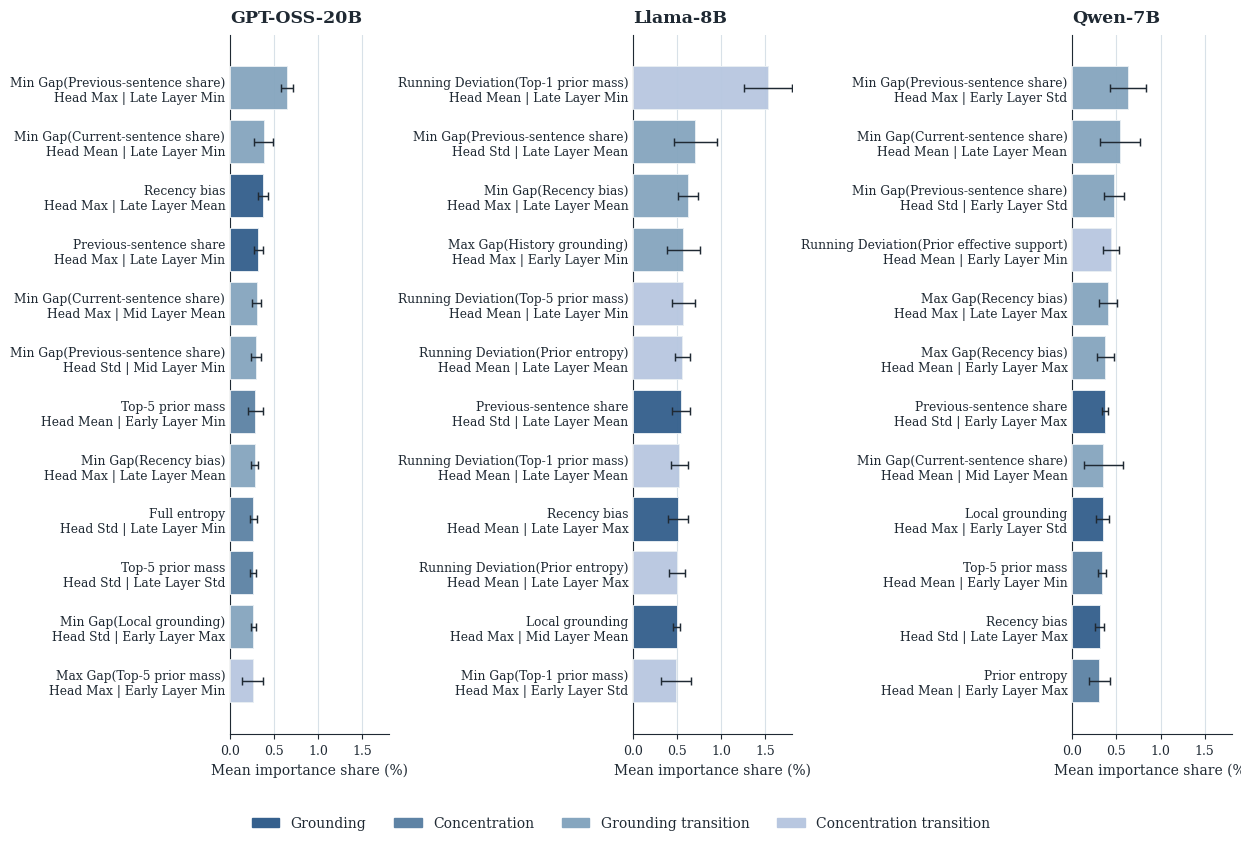

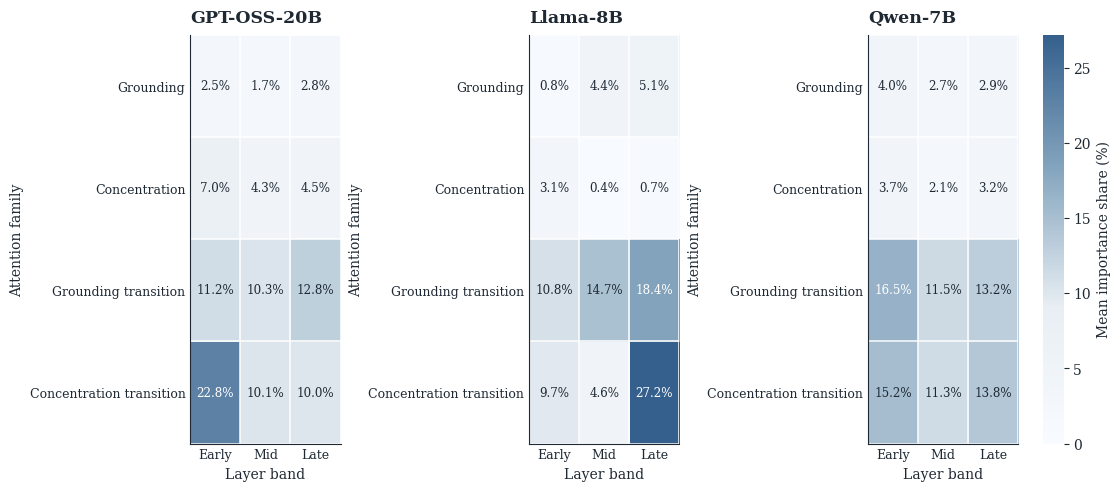

#### Attention Family By Layer Band Tables

##### GPT-OSS-20B

band,Attention Family,Early,Mid,Late
0,Grounding,2.5%,1.7%,2.8%
1,Concentration,7.0%,4.3%,4.5%
2,Grounding transition,11.2%,10.3%,12.8%
3,Concentration transition,22.8%,10.1%,10.0%


##### Llama-8B

band,Attention Family,Early,Mid,Late
0,Grounding,0.8%,4.4%,5.1%
1,Concentration,3.1%,0.4%,0.7%
2,Grounding transition,10.8%,14.7%,18.4%
3,Concentration transition,9.7%,4.6%,27.2%


...

,Rank,Feature,Mean Importance Share,SE,Group,Band,Stat,Head Summary
0,1,Min Gap(Previous-sentence share),0.65%,0.07%,Grounding transition,Late,Min,Head Max
1,2,Min Gap(Current-sentence share),0.38%,0.11%,Grounding transition,Late,Min,Head Mean
2,3,Recency bias,0.37%,0.06%,Grounding,Late,Mean,Head Max
3,4,Previous-sentence share,0.32%,0.05%,Grounding,Late,Min,Head Max
4,5,Min Gap(Current-sentence share),0.30%,0.05%,Grounding transition,Mid,Mean,Head Max
5,6,Min Gap(Previous-sentence share),0.29%,0.06%,Grounding transition,Mid,Min,Head Std
6,7,Top-5 prior mass,0.29%,0.08%,Concentration,Early,Min,Head Mean
7,8,Min Gap(Recency bias),0.28%,0.04%,Grounding transition,Late,Mean,Head Max
8,9,Full entropy,0.26%,0.04%,Concentration,Late,Min,Head Std
9,10,Top-5 prior mass,0.26%,0.04%,Concentration,Late,Std,Head Std


##### Llama-8B
- OOD AUROC: `0.613 +/- 0.033`
- Validation AUROC: `0.736 +/- 0.014`
- Training splits averaged: `5`

,Rank,Feature,Mean Importance Share,SE,Group,Band,Stat,Head Summary
0,1,Running Deviation(Top-1 prior mass),1.53%,0.27%,Concentration transition,Late,Min,Head Mean
1,2,Min Gap(Previous-sentence share),0.70%,0.24%,Grounding transition,Late,Mean,Head Std
2,3,Min Gap(Recency bias),0.62%,0.11%,Grounding transition,Late,Mean,Head Max
3,4,Max Gap(History grounding),0.57%,0.19%,Grounding transition,Early,Min,Head Max
4,5,Running Deviation(Top-5 prior mass),0.57%,0.13%,Concentration transition,Late,Min,Head Mean
5,6,Running Deviation(Prior entropy),0.56%,0.09%,Concentration transition,Late,Mean,Head Mean
6,7,Previous-sentence share,0.54%,0.10%,Grounding,Late,Mean,Head Std
7,8,Running Deviation(Top-1 prior mass),0.52%,0.09%,Concentration transition,Late,Mean,Head Mean
8,9,Recency bias,0.51%,0.12%,Grounding,Late,Max,Head Mean
9,10,Running Deviation(Prior entropy),0.50%,0.09%,Concentration transition,Late,Max,Head Mean


##### Qwen-7B
- OOD AUROC: `0.734 +/- 0.010`
- Validation AUROC: `0.783 +/- 0.005`
- Training splits averaged: `5`

,Rank,Feature,Mean Importance Share,SE,Group,Band,Stat,Head Summary
0,1,Min Gap(Previous-sentence share),0.63%,0.20%,Grounding transition,Early,Std,Head Max
1,2,Min Gap(Current-sentence share),0.54%,0.23%,Grounding transition,Late,Mean,Head Mean
2,3,Min Gap(Previous-sentence share),0.47%,0.11%,Grounding transition,Early,Std,Head Std
3,4,Running Deviation(Prior effective support),0.44%,0.09%,Concentration transition,Early,Min,Head Mean
4,5,Max Gap(Recency bias),0.40%,0.10%,Grounding transition,Late,Max,Head Max
5,6,Max Gap(Recency bias),0.38%,0.10%,Grounding transition,Early,Max,Head Mean
6,7,Previous-sentence share,0.37%,0.03%,Grounding,Early,Max,Head Std
7,8,Min Gap(Current-sentence share),0.35%,0.22%,Grounding transition,Mid,Mean,Head Mean
8,9,Local grounding,0.34%,0.07%,Grounding,Early,Std,Head Max
9,10,Top-5 prior mass,0.34%,0.05%,Concentration,Early,Min,Head Mean


In [3]:
results = attention_importance.render_attention_feature_importance_notebook(
    results_root=RESULTS_ROOT,
    top_k=12,
    export_figures=False,
)
